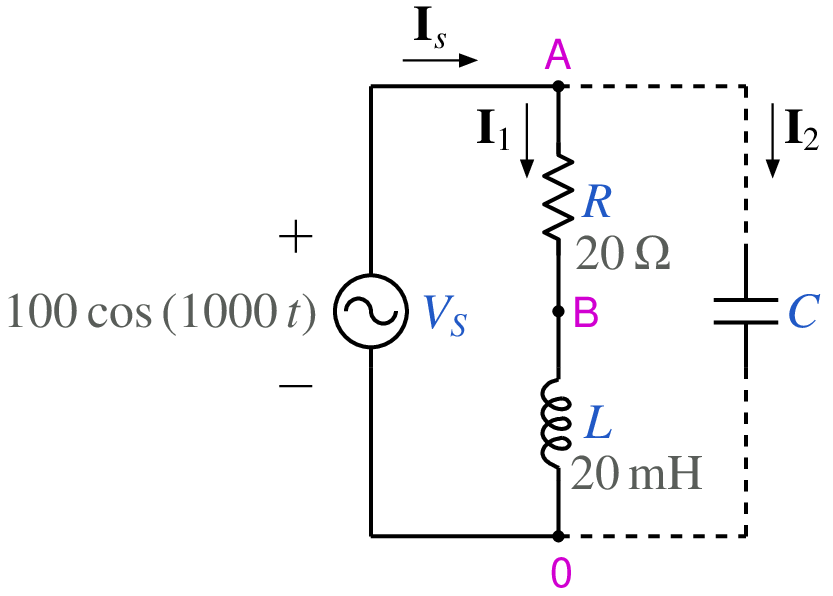

In [8]:
from IPython.display import Image
Image(filename =r'Animation_phasor_3A_fig_1.png', width=320)

In [1]:
netlist = """\
RLC Parallel Circuit - Phasor Locus vs C
Vs    a    0    AC  100  0
VR    a    b1   0
R1    b1   b    20
L1    b    0    0.02
VC    a    nc   0
C1    nc   0    $C
.SAVE v(a) v(b) i(vs) i(vr) i(vc)
.AC LIN 1 $F $F
.END
"""

with open('Animation_phasor_3A_orig.in', 'w') as f:
    f.write(netlist)

print('Animation_phasor_3A_orig.in written')


Animation_phasor_3A_orig.in written


In [ ]:

%pycat Animation_phasor_3A_orig.in


RLC Parallel Circuit - Phasor Locus vs C
Vs    a    0    AC  100  0
VR    a    b1   0
R1    b1   b    20
L1    b    0    0.02
VC    a    nc   0
C1    nc   0    $C
.SAVE v(a) v(b) i(vs) i(vr) i(vc)
.AC LIN 1 $F $F
.END


In [ ]:
import numpy as np
import ngspice_calc as calc


R     = 20.0          # ohm
L     = 0.02           # H
omega = 1000.0          # rad/s  (Vs(t) = 100 cos(1000 t))
freq  = omega / (2*np.pi)

NC1   = 60
C_arr = np.linspace(1.0e-6, 60.0e-6, NC1)

IR1 = []
IC1 = []
Is1 = []
Vs1 = []

SR1 = []
SC1 = []
SL1 = []
SV1 = []

for C in C_arr:
    s_C = "%11.4E" % C
    s_F = "%.6f" % freq

    l = [
        ('$C', s_C),
        ('$F', s_F),
    ]
    print('C:', "%5.1E" % C)
    calc.replace_strings_1("Animation_phasor_3A_orig.in", "Animation_phasor_3A.in", l)

    calc.run_ngspice("Animation_phasor_3A.in")

    s = calc.slv("Animation_phasor_3A.in")

    Va   = s.get_array('v(a)')[0]
    Vb   = s.get_array('v(b)')[0]
    i_vs = s.get_array('i(vs)')[0]
    i_vr = s.get_array('i(vr)')[0]
    i_vc = s.get_array('i(vc)')[0]

    #  branch voltages
    Vs_ac = Va          
    VR_ac = Va - Vb    
    VL_ac = Vb          
    VC_ac = Va         
    
    IR_ac = i_vr
    IC_ac = i_vc
    Is_ac = -i_vs

    IR1.append(IR_ac)
    IC1.append(IC_ac)
    Is1.append(Is_ac)
    Vs1.append(Vs_ac)

    # complex power S = (1/2) V * conj(I) 
    SR1.append(0.5 * VR_ac * np.conj(IR_ac))   
    SL1.append(0.5 * VL_ac * np.conj(IR_ac))
    SC1.append(0.5 * VC_ac * np.conj(IC_ac))
    SV1.append(0.5 * Vs_ac * np.conj(Is_ac))

np_Vs = (np.array(Vs1)) / 100.0
Vs1 = list(np_Vs)

np_IR = np.array(IR1)
np_IC = np.array(IC1)
np_Is = np.array(Is1)

real_IR = list(np_IR.real)
real_IC = list(np_IC.real)
real_Is = list(np_Is.real)
real_Vs = list(np_Vs.real)

imag_IR = list(np_IR.imag)
imag_IC = list(np_IC.imag)
imag_Is = list(np_Is.imag)
imag_Vs = list(np_Vs.imag)

np_SR = np.array(SR1)
np_SC = np.array(SC1)
np_SL = np.array(SL1)
np_SV = np.array(SV1)

real_SR = list(np_SR.real)
real_SC = list(np_SC.real)
real_SL = list(np_SL.real)
real_SV = list(np_SV.real)

imag_SR = list(np_SR.imag)
imag_SC = list(np_SC.imag)
imag_SL = list(np_SL.imag)
imag_SV = list(np_SV.imag)


C: 1.0E-06

No compatibility mode selected!


Circuit: rlc parallel circuit - phasor locus vs c

binary raw file "Animation_phasor_3A.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 6  

No. of Data Rows : 1

Total analysis time (seconds) = 0

Total elapsed time (seconds) = 0.003 

Total DRAM available = 14741.160 MB.
DRAM currently available = 2354.387 MB.
Maximum ngspice program size =   19.906 MB.
Current ngspice program size =   11.973 MB.

Shared ngspice pages =   10.117 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.961 MB.


C: 2.0E-06

No compatibility mode selected!


Circuit: rlc parallel circuit - phasor locus vs c

binary raw file "Animation_phasor_3A.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 6  

No. of Data Rows : 1

Total analysis time (seconds) = 0.001

Total elapsed time (seconds) = 0.003 

Total DRAM available = 14741.160 MB.
DRAM currently available = 2354.387 MB

In [ ]:
import math

def phasor_append_1(l3, l_labels, z, label):
    """Append a complex phasor value and its label to the working lists.
    """
    l3.append(z)
    l_labels.append(label)


def phasor_2(l3, theta_deg, length_arrow, frac):
    """Build (xdata, ydata) line segments to draw each phasor in l3
    as an arrow: one line for the shaft (origin -> tip) and two short
    lines forming the arrowhead at the tip.

    theta_deg    : half-angle of the arrowhead, in degrees
    length_arrow : nominal length of each arrowhead stroke
    frac         : the arrowhead stroke length is capped at
                    frac * |z|, so very short phasors get a
                    proportionally small arrowhead.

    Returns (lines,) where lines is a flat list of (xdata, ydata)
    tuples, 3 entries per phasor (shaft, head-line-1, head-line-2).
    """
    theta = math.radians(theta_deg)
    lines = []

    for z in l3:
        x1, y1 = z.real, z.imag
        mag = math.hypot(x1, y1)

        head_len = length_arrow
        if mag > 0:
            head_len = min(length_arrow, frac * mag)

        phi = math.atan2(y1, x1)

        shaft_x = [0.0, x1]
        shaft_y = [0.0, y1]

        hx1 = x1 - head_len * math.cos(phi - theta)
        hy1 = y1 - head_len * math.sin(phi - theta)
        hx2 = x1 - head_len * math.cos(phi + theta)
        hy2 = y1 - head_len * math.sin(phi + theta)

        lines.append((shaft_x, shaft_y))
        lines.append(([x1, hx1], [y1, hy1]))
        lines.append(([x1, hx2], [y1, hy2]))

    return (lines,)


In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
fig.set_size_inches(8, 5)

xmin = min(real_IR + real_IC + real_Is + real_Vs) - 0.5
xmax = max(real_IR + real_IC + real_Is + real_Vs) + 0.5
ymin = min(imag_IR + imag_IC + imag_Is + imag_Vs) - 0.5
ymax = max(imag_IR + imag_IC + imag_Is + imag_Vs) + 0.5

ax.set_aspect('equal', adjustable='box')
ax.set(xlim=[xmin, xmax], ylim=[ymin, ymax])

plt.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

plt.xlabel('$Re$', fontsize=12)
plt.ylabel('$Im$', fontsize=12)

fig.suptitle('Note: units are A, V', fontsize=12)

c_Is = 'blue'
c_IR = 'red'
c_IC = 'green'
c_Vs = 'grey'

line_Is = ax.plot([], [], color=c_Is, linestyle='--', linewidth=0.8, dashes=(3,3))[0]

line2_Is = []
line2_IR = []
line2_IC = []
line2_Vs = []

for i in range(3):
    if i == 0:
        line1_Is = ax.plot([], [], color=c_Is, linewidth=1.0, label='$I_s$')[0]
        line1_IR = ax.plot([], [], color=c_IR, linewidth=1.0, label='$I_R$')[0]
        line1_IC = ax.plot([], [], color=c_IC, linewidth=1.0, label='$I_C$')[0]
        line1_Vs = ax.plot([], [], color=c_Vs, linewidth=1.0, label='$V_s/100$')[0]
    else:
        line1_Is = ax.plot([], [], color=c_Is, linewidth=1.0)[0]
        line1_IR = ax.plot([], [], color=c_IR, linewidth=1.0)[0]
        line1_IC = ax.plot([], [], color=c_IC, linewidth=1.0)[0]
        line1_Vs = ax.plot([], [], color=c_Vs, linewidth=1.0)[0]

    line2_Is.append(line1_Is)
    line2_IR.append(line1_IR)
    line2_IC.append(line1_IC)
    line2_Vs.append(line1_Vs)

ax.legend(loc='lower left', fontsize=11, bbox_to_anchor=(1.05, 0.0))

l3_Is = []
l3_IR = []
l3_IC = []
l3_Vs = []

l_labels_Is = []
l_labels_IR = []
l_labels_IC = []
l_labels_Vs = []

props = dict(boxstyle='round', facecolor='grey', alpha=0.15)  # bbox features
text1 = ax.text(1.03, 0.98, '', transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)
theta_deg = 20.0
length_arrow = 0.08 * (xmax - xmin)

def update(frame):
    line_Is.set_xdata(real_Is[:frame+1])
    line_Is.set_ydata(imag_Is[:frame+1])

    l3_Is.clear()
    l_labels_Is.clear()
    phasor_append_1(l3_Is, l_labels_Is, Is1[frame], "$I_s$")
    l4_Is = phasor_2(l3_Is, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_Is[0]):
        line2_Is[k].set_xdata(t[0])
        line2_Is[k].set_ydata(t[1])

    l3_IR.clear()
    l_labels_IR.clear()
    phasor_append_1(l3_IR, l_labels_IR, IR1[frame], "$I_R$")
    l4_IR = phasor_2(l3_IR, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_IR[0]):
        line2_IR[k].set_xdata(t[0])
        line2_IR[k].set_ydata(t[1])

    l3_IC.clear()
    l_labels_IC.clear()
    phasor_append_1(l3_IC, l_labels_IC, IC1[frame], "$I_C$")
    l4_IC = phasor_2(l3_IC, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_IC[0]):
        line2_IC[k].set_xdata(t[0])
        line2_IC[k].set_ydata(t[1])

    l3_Vs.clear()
    l_labels_Vs.clear()
    phasor_append_1(l3_Vs, l_labels_Vs, Vs1[frame], "$V_s$")
    l4_Vs = phasor_2(l3_Vs, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_Vs[0]):
        line2_Vs[k].set_xdata(t[0])
        line2_Vs[k].set_ydata(t[1])

    text1.set_text(
      r'$C$' + ' = %4.0f' % (C_arr[frame]*1e6) + r' $\mu$F'
    )
    return

anim = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=NC1,
    interval=500,
    repeat=False)

plt.tight_layout()
plt.close()

HTML(anim.to_jshtml())


In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
fig.set_size_inches(8, 5)

xmin = min(real_SR + real_SC + real_SL + real_SV) - 25.0
xmax = max(real_SR + real_SC + real_SL + real_SV) + 25.0
ymin = min(imag_SR + imag_SC + imag_SL + imag_SV) - 25.0
ymax = max(imag_SR + imag_SC + imag_SL + imag_SV) + 25.0

ax.set_aspect('equal', adjustable='box')
ax.set(xlim=[xmin, xmax], ylim=[ymin, ymax])

plt.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

plt.xlabel('$Re (S)$', fontsize=12)
plt.ylabel('$Im (S)$', fontsize=12)

fig.suptitle('Note: S in VA', fontsize=12)

c_SV = 'blue'
c_SR = 'red'
c_SC = 'green'
c_SL = 'goldenrod'

line_SV = ax.plot([], [], color=c_SV, linestyle='--', linewidth=0.8, dashes=(3,3))[0]

line2_SV = []
line2_SR = []
line2_SC = []
line2_SL = []

for i in range(3):
    if i == 0:
        line1_SV = ax.plot([], [], color=c_SV, linewidth=1.0, label='$S_{Vs}$')[0]
        line1_SR = ax.plot([], [], color=c_SR, linewidth=1.0, label='$S_R$')[0]
        line1_SC = ax.plot([], [], color=c_SC, linewidth=1.0, label='$S_C$')[0]
        line1_SL = ax.plot([], [], color=c_SL, linewidth=1.0, label='$S_L$')[0]
    else:
        line1_SV = ax.plot([], [], color=c_SV, linewidth=1.0)[0]
        line1_SR = ax.plot([], [], color=c_SR, linewidth=1.0)[0]
        line1_SC = ax.plot([], [], color=c_SC, linewidth=1.0)[0]
        line1_SL = ax.plot([], [], color=c_SL, linewidth=1.0)[0]

    line2_SV.append(line1_SV)
    line2_SR.append(line1_SR)
    line2_SC.append(line1_SC)
    line2_SL.append(line1_SL)

ax.legend(loc='lower left', fontsize=11, bbox_to_anchor=(1.05, 0.0))

l3_SV = []
l3_SR = []
l3_SC = []
l3_SL = []

l_labels_SV = []
l_labels_SR = []
l_labels_SC = []
l_labels_SL = []

props = dict(boxstyle='round', facecolor='grey', alpha=0.15)  # bbox features
text1 = ax.text(1.03, 0.98, '', transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)
theta_deg = 20.0
length_arrow = 0.08 * (xmax - xmin)

def update(frame):
    line_SV.set_xdata(real_SV[:frame+1])
    line_SV.set_ydata(imag_SV[:frame+1])

    l3_SV.clear()
    l_labels_SV.clear()
    phasor_append_1(l3_SV, l_labels_SV, SV1[frame], "$S_{Vs}$")
    l4_SV = phasor_2(l3_SV, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_SV[0]):
        line2_SV[k].set_xdata(t[0])
        line2_SV[k].set_ydata(t[1])

    l3_SR.clear()
    l_labels_SR.clear()
    phasor_append_1(l3_SR, l_labels_SR, SR1[frame], "$S_R$")
    l4_SR = phasor_2(l3_SR, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_SR[0]):
        line2_SR[k].set_xdata(t[0])
        line2_SR[k].set_ydata(t[1])

    l3_SC.clear()
    l_labels_SC.clear()
    phasor_append_1(l3_SC, l_labels_SC, SC1[frame], "$S_C$")
    l4_SC = phasor_2(l3_SC, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_SC[0]):
        line2_SC[k].set_xdata(t[0])
        line2_SC[k].set_ydata(t[1])

    l3_SL.clear()
    l_labels_SL.clear()
    phasor_append_1(l3_SL, l_labels_SL, SL1[frame], "$S_L$")
    l4_SL = phasor_2(l3_SL, theta_deg, length_arrow, 0.4)

    for k, t in enumerate(l4_SL[0]):
        line2_SL[k].set_xdata(t[0])
        line2_SL[k].set_ydata(t[1])

    text1.set_text(
      r'$C$' + ' = %4.0f' % (C_arr[frame]*1e6) + r' $\mu$F'
    )
    return

anim = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=NC1,
    interval=500,
    repeat=False)

plt.tight_layout()
plt.close()

HTML(anim.to_jshtml())
